Extracting features from: ../data/processed/normal_gait_with_angles.csv
Extracting features from: ../data/processed/stiff_knee_with_angles.csv

Training Random Forest Classifier...

Model Accuracy: 83.33%

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.53      0.69        34
   Stiff (1)       0.79      1.00      0.89        62

    accuracy                           0.83        96
   macro avg       0.90      0.76      0.79        96
weighted avg       0.87      0.83      0.82        96



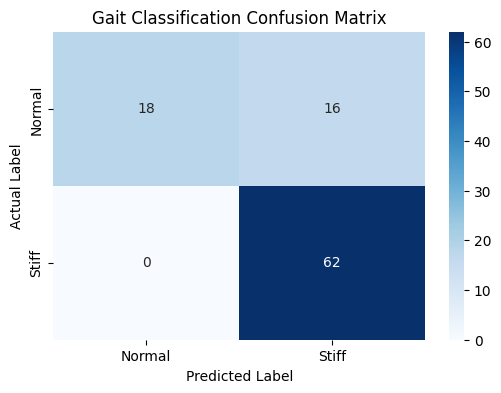

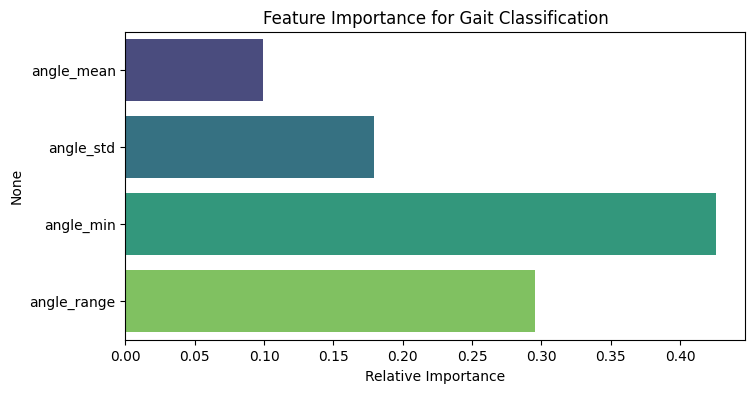

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def engineer_features(csv_path, label, window_size=15):
    """
    Reads kinematic data and extracts rolling statistical features.
    label: 0 for Normal, 1 for Abnormal (Stiff)
    """
    print(f"Extracting features from: {csv_path}")
    df = pd.read_csv(csv_path)
    
    # Calculate rolling statistics over a window of frames
    df['angle_mean'] = df['knee_angle_smoothed'].rolling(window=window_size).mean()
    df['angle_std'] = df['knee_angle_smoothed'].rolling(window=window_size).std() # Captures movement variation
    df['angle_min'] = df['knee_angle_smoothed'].rolling(window=window_size).min() # Peak flexion
    df['angle_max'] = df['knee_angle_smoothed'].rolling(window=window_size).max() # Peak extension
    df['angle_range'] = df['angle_max'] - df['angle_min'] # Total range of motion in that window
    
    # Drop rows with NaN values created by the rolling window
    df = df.dropna().copy()
    
    # Add our target label
    df['label'] = label
    
    # Select only our engineered features for the ML model
    features_df = df[['angle_mean', 'angle_std', 'angle_min', 'angle_range', 'label']]
    return features_df

# 1. Process both datasets
# Label 0 = Normal Gait, Label 1 = Stiff Knee
normal_features = engineer_features('../data/processed/normal_gait_with_angles.csv', label=0)
stiff_features = engineer_features('../data/processed/stiff_knee_with_angles.csv', label=1)

# 2. Combine into a single ML dataset
ml_df = pd.concat([normal_features, stiff_features], ignore_index=True)

# 3. Define Inputs (X) and Target (y)
X = ml_df.drop('label', axis=1)
y = ml_df['label']

# 4. Train/Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Initialize and Train the Random Forest Model
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 6. Make Predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 7. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Stiff (1)']))

# 8. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Stiff'], yticklabels=['Normal', 'Stiff'])
plt.title('Gait Classification Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 9. Feature Importance (What did the AI care about most?)
importances = rf_model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=feature_names, palette='viridis', hue=feature_names, legend=False)
plt.title('Feature Importance for Gait Classification')
plt.xlabel('Relative Importance')
plt.show()